<a href="https://colab.research.google.com/github/SarthakGupta345/PytorchLearning/blob/main/RNNINDeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
print("Hello wordl")

Hello wordl


In [13]:
!pip install opendatasets --quiet

In [14]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sarthakgupta8965904
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:05<00:00, 136MB/s]


In [16]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader,Dataset
from torchvision.datasets import ImageFolder
from PIL import Image
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt




In [17]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
print("Device is ",device)

Device is  cuda


In [18]:
image_path = [] # Empty array where we will fill the paths of the images
labels = [] # Empty array where we will fill the labes of the images

for i in os.listdir("/content/animal-faces/afhq/"): # Looping through the first directory which has the train and val images
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"): # Looping through the first directory which has the labels folders
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"): # Looping through all the images of this label
      labels.append(label) # Append/Put this label in the list
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}") # Append/Put this image path in the list to read it later

data_df = pd.DataFrame(zip(image_path, labels), columns = ['image_paths', 'labels']) # Create a dataframe contains the images paths and the labels
data_df.head() # Visualizing the first 5 rows


,image_paths,labels
0,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
1,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
2,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
3,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
4,/content/animal-faces/afhq/train/cat/pixabay_c...,cat


In [19]:
train=data_df.sample(frac=0.7,random_state=7) # Create training of 70% of the data
test=data_df.drop(train.index) # Create testing by removing the 70% of the train data which will result in 30%

val=test.sample(frac=0.5,random_state=7) # Create validation of 50% of the testing data
test=test.drop(val.index)

In [20]:
train

,image_paths,labels
12388,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
6596,/content/animal-faces/afhq/train/wild/pixabay_...,wild
5367,/content/animal-faces/afhq/train/wild/flickr_w...,wild
13331,/content/animal-faces/afhq/train/dog/flickr_do...,dog
14958,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
...,...,...
12325,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
12924,/content/animal-faces/afhq/train/dog/flickr_do...,dog
4296,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
14644,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [21]:
len(train)
len(data_df)

16130

In [22]:
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(train['labels'])
train['labels'] = label_encoder.transform(train['labels'])


In [23]:
test

,image_paths,labels
7,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
14,/content/animal-faces/afhq/train/cat/flickr_ca...,cat
18,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
29,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
31,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
...,...,...
16060,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
16065,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog
16078,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
16093,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog


In [24]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32)

])

In [25]:
train

,image_paths,labels
12388,/content/animal-faces/afhq/train/dog/pixabay_d...,1
6596,/content/animal-faces/afhq/train/wild/pixabay_...,2
5367,/content/animal-faces/afhq/train/wild/flickr_w...,2
13331,/content/animal-faces/afhq/train/dog/flickr_do...,1
14958,/content/animal-faces/afhq/val/cat/pixabay_cat...,0
...,...,...
12325,/content/animal-faces/afhq/train/dog/pixabay_d...,1
12924,/content/animal-faces/afhq/train/dog/flickr_do...,1
4296,/content/animal-faces/afhq/train/cat/pixabay_c...,0
14644,/content/animal-faces/afhq/val/cat/pixabay_cat...,0


In [26]:
test

,image_paths,labels
7,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
14,/content/animal-faces/afhq/train/cat/flickr_ca...,cat
18,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
29,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
31,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
...,...,...
16060,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
16065,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog
16078,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
16093,/content/animal-faces/afhq/val/dog/flickr_dog_...,dog


In [27]:

class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
          image = self.transform(image).to(device)

        return image, label

In [28]:
global label_encoder
label_encoder = LabelEncoder()
# Fit the encoder on all unique labels from the *original* string labels to ensure consistency.
# This is critical if the global label_encoder was previously corrupted by re-fitting on numerical data.
label_encoder.fit(data_df['labels'])

# train['labels'] was modified in place in Zx-3NGGFcQR1 to be numerical.
# The CustomImageDataset class calls label_encoder.transform(dataframe['labels']).
# If train['labels'] is numerical, and label_encoder is now correctly fitted on strings,
# calling transform on numerical data will raise 'y contains previously unseen labels'.
# To prevent this, we create a temporary train dataframe using original string labels from data_df.
temp_train_df = data_df.loc[train.index].copy()
train_dataset = CustomImageDataset(dataframe=temp_train_df, transform=transform)

# val['labels'] and test['labels'] still contain string labels.
# With the label_encoder now correctly fitted on strings, these transformations will work as expected.
val_dataset = CustomImageDataset(dataframe=val, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)

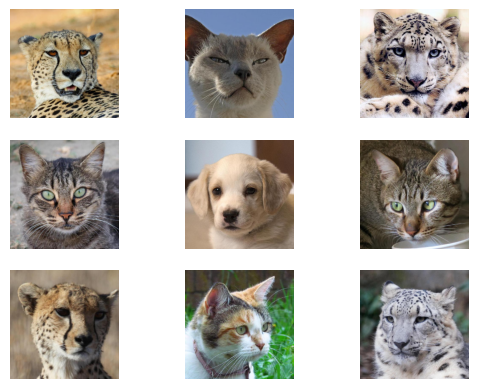

In [29]:

n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(data_df.sample(n = 1)['image_paths'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()

In [40]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 5

In [31]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [32]:
data_df

,image_paths,labels
0,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
1,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
2,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
3,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
4,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
...,...,...
16125,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
16126,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
16127,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog
16128,/content/animal-faces/afhq/val/dog/pixabay_dog...,dog


In [33]:
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3,32,kernel_size=3,padding=1)
    self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1)
    self.conv3 = nn.Conv2d(64,128,kernel_size=3,padding =1)
    self.pooling = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 128)
    self.output = nn.Linear(128,len(data_df['labels'].unique()))

  def forward(self,x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)
    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)
    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x

model = MyModel().to(device)

In [35]:
from torchsummary import summary
summary(model,(3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [51]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(),lr=LR)

In [42]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__() * 100, 4)}''')
  print("="*25)

Epoch 1/5, Train Loss: 1.2275 Train Accuracy 93.579
              Validation Loss: 0.2505 Validation Accuracy: 93.843
Epoch 2/5, Train Loss: 0.7953 Train Accuracy 95.9702
              Validation Loss: 0.1832 Validation Accuracy: 95.4545
Epoch 3/5, Train Loss: 0.5716 Train Accuracy 97.0773
              Validation Loss: 0.1965 Validation Accuracy: 95.4959
Epoch 4/5, Train Loss: 0.407 Train Accuracy 97.8833
              Validation Loss: 0.1839 Validation Accuracy: 95.7438
Epoch 5/5, Train Loss: 0.3107 Train Accuracy 98.3615
              Validation Loss: 0.1856 Validation Accuracy: 95.9917


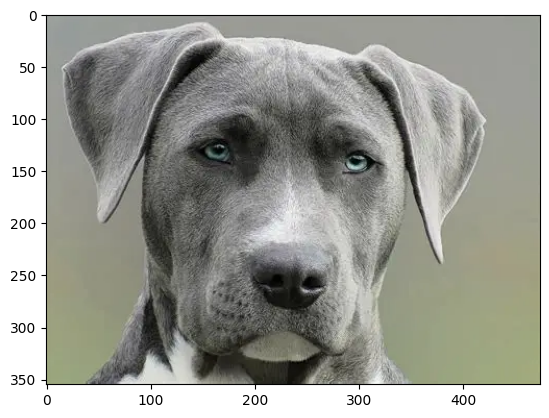


Prediction: 



array(['dog'], dtype=object)

In [50]:
import requests
from io import BytesIO

def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis = 1).item()
  return label_encoder.inverse_transform([output])

## Visualize the image
image_url = "https://tse2.mm.bing.net/th/id/OIP.WKjYa3e1mxqFTn06sqiQJAHaFj?cb=ucfimg2&ucfimg=1&rs=1&pid=ImgDetMain&o=7&rm=3"
response = requests.get(image_url)
image_data = BytesIO(response.content)
image = Image.open(image_data).convert('RGB')
plt.imshow(image)
plt.show()


## Predict
print()
print("Prediction: \n")
predict_image(image_data)